# 03 – Modelado: Optuna + Ensambles + Meta-Ensamble

| Campo | Detalle |
|---|---|
| **Input** | `data_hotel_booking/train_fe.csv` · `val_fe.csv` · `test_fe.csv` |
| **Output** | `data_hotel_booking/test_predictions.csv` · Figuras en `Figures/Modelling/` · Estudios Optuna en `Studies_optuna/` |
| **Target** | `is_canceled_num` — 1 = Cancelado · 0 = No cancelado |
| **Modelos base** | LightGBM · XGBoost · Random Forest |
| **Estrategia de modelado** | Búsqueda bayesiana (Optuna) → Bagging por semillas → Ensamble promedio y ponderado → Meta-Ensamble por Stacking |
| **Búsqueda de hiperparámetros** | Optuna con `TimeSeriesSplit` (5 folds) sobre Train — 30 trials LGBM · 30 trials XGB · 20 trials RF · Persistencia en SQLite (reanudable) |
| **Bagging** | 10 modelos por algoritmo entrenados con semillas distintas — las probabilidades se promedian para reducir varianza |
| **Ensambles** | Promedio aritmético · Promedio ponderado por AUC en Val |
| **Meta-Ensamble** | Stacking con OOF (Out-of-Fold) sobre Train como meta-features · Meta-learner: Regresión Logística |
| **Métrica principal** | ROC AUC — complementada con ganancia económica (€) basada en ADR |
| **Umbral** | Optimizado por máxima ganancia económica sobre Val · Aplicado una sola vez sobre Test |
| **Validación** | Optuna y OOF sobre Train · Selección de modelo y umbral sobre Val · Evaluación final sobre Test (tocado una sola vez) |


In [ ]:
#  Correr una sola vez para preparar el entorno
# %pip install optuna pandas numpy scikit-learn xgboost lightgbm catboost matplotlib seaborn

# 1. Configuración global


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIG — editar aquí para controlar el experimento
# ══════════════════════════════════════════════════════════════════════════════

EXP           = "Exp001"    # Prefijo para los estudios SQLite de Optuna por su uno quisiera explorar varias FeatEng o diferentes cosas a posteriori.
BASE_SEED     = 8           # Semilla base para reproducibilidad

N_TRIALS_LGBM = 50          # Nro de trials de búsqueda bayesiana por modelo
N_TRIALS_XGB  = 50
N_TRIALS_RF   = 50

N_MODELOS     = 10          # Modelos por algoritmo en el bagging de semillas
N_FOLD_CV     = 5           # Splits del TimeSeriesSplit en Optuna

# 2. Imports y utilidades


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import os
import warnings
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
np.random.seed(BASE_SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH   = Path.cwd() / "data_hotel_booking"
STUDY_DIR   = Path("Studies_optuna")
FIGURES_DIR = Path("Figures") / "Modelling"
STUDY_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def get_study_db(study_id):
    return f"sqlite:///{STUDY_DIR}/{study_id}.db"

def logging_callback(study, frozen_trial):
    if frozen_trial.number % 5 == 0 or frozen_trial.number == 0:
        print(f"  [Trial {frozen_trial.number:3d}] AUC={frozen_trial.value:.4f} | Mejor={study.best_value:.4f}")

print("✅ Configuración lista.")

✅ Configuración lista.


# 3. Carga de los tres splits (output de 02_FeatEng.ipynb)


In [ ]:
TARGET = 'is_canceled_num'

df_train_raw = pd.read_csv(DATA_PATH / "train_fe.csv")
df_val_raw   = pd.read_csv(DATA_PATH / "val_fe.csv")
df_test_raw  = pd.read_csv(DATA_PATH / "test_fe.csv")

# ── Separar features y target ────────────────────────────
X_train, y_train = df_train_raw.drop(columns=[TARGET]), df_train_raw[TARGET].astype(int)
X_val,   y_val   = df_val_raw.drop(columns=[TARGET]),   df_val_raw[TARGET].astype(int)
X_test,  y_test  = df_test_raw.drop(columns=[TARGET]),  df_test_raw[TARGET].astype(int)

# ── Limpiar inf / nan residuales si los hubiera ──────────
for X in [X_train, X_val, X_test]:
    X.replace([float('inf'), float('-inf')], float('nan'), inplace=True)
    X.fillna(0, inplace=True)

print(f"Train : {X_train.shape[0]:6,} filas | {X_train.shape[1]} features | Tasa cancelación: {y_train.mean():.2%}")
print(f"Val   : {X_val.shape[0]:6,} filas | {X_val.shape[1]} features | Tasa cancelación: {y_val.mean():.2%}")
print(f"Test  : {X_test.shape[0]:6,} filas | {X_test.shape[1]} features | Tasa cancelación: {y_test.mean():.2%}")


Train : 108,738 filas | 47 features | Tasa cancelación: 36.98%
Val   :  5,308 filas | 47 features | Tasa cancelación: 37.38%
Test  :  4,923 filas | 47 features | Tasa cancelación: 36.85%


# 4. Métrica de negocio 

### 4.1  Funcion de ganancia para revenue management

El modelo en si predice si una reserva va a cancelarse. Desde el punto de vista del hotel o de revenue management, lo que importa no es el AUC  o lo que mide el modelo, sino es cuánto dinero se gana o se pierde con cada predicción.

Cada predicción del modelo tiene un impacto económico distinto:

| Predicción | Realidad | Nombre | Impacto económico |
|---|---|---|---|
| Cancela | Cancela | **TP** | ✅ El hotel  re-vende la habitación → **GANANCIA** |
| Cancela | No cancela | **FP** | ❌ El hotel actuó sobre una reserva válida → **COSTO** |
| No cancela | No cancela | **TN** | Sin impacto — no se tomó ninguna acción |
| No cancela | Cancela | **FN** | Costo de oportunidad implícito — se perdió la chance de re-vender |


**DEFINICION:**  La función de ganancia es:

```
Ganancia neta = TP × BENEFICIO_TP  −  FP × COSTO_FP
```

In [ ]:
adr_cancel    = df_train_raw.loc[df_train_raw[TARGET] == 1, 'adr'].mean()
adr_no_cancel = df_train_raw.loc[df_train_raw[TARGET] == 0, 'adr'].mean()

noches_cancel    = df_train_raw.loc[df_train_raw[TARGET] == 1, 'total_nights'].mean()
noches_no_cancel = df_train_raw.loc[df_train_raw[TARGET] == 0, 'total_nights'].mean()

valor_reserva_cancel    = adr_cancel    * noches_cancel
valor_reserva_no_cancel = adr_no_cancel * noches_no_cancel

print("── Componentes base ────────────────────────────────────────────")
print(f"  ADR medio canceladas        : €{adr_cancel:.2f}/noche")
print(f"  ADR medio no canceladas     : €{adr_no_cancel:.2f}/noche")
print(f"  Noches medias canceladas    : {noches_cancel:.1f}")
print(f"  Noches medias no canceladas : {noches_no_cancel:.1f}")
print(f"  Valor medio reserva cancelada    : €{valor_reserva_cancel:.2f}")
print(f"  Valor medio reserva no cancelada : €{valor_reserva_no_cancel:.2f}")

── Componentes base ────────────────────────────────────────────
  ADR medio canceladas        : €100.05/noche
  ADR medio no canceladas     : €95.50/noche
  Noches medias canceladas    : 3.4
  Noches medias no canceladas : 3.3
  Valor medio reserva cancelada    : €339.86
  Valor medio reserva no cancelada : €318.96


## 4.2 ¿Por qué no usar solo el ADR promedio?


La formulación más simple sería:

```python
BENEFICIO_TP = ADR medio de reservas canceladas   # ~€102
COSTO_FP     = ADR medio de reservas no canceladas # ~€99
```

El problema es que la diferencia es de ~€3, lo que hace la función casi simétrica. 


## 4.3 Parámetros de negocio configurables

**`BENEFICIO_TP`** — ¿Cuánto gana el hotel cuando detecta una cancelación real?

El hotel puede re-vender la habitación liberada, pero no siempre lo logra.
`TASA_REOCUPACION` modela qué porcentaje de habitaciones detectadas se re-venden.


**`COSTO_FP`** — ¿Cuánto le cuesta al hotel un falso positivo?

Si el modelo predice cancelación y el cliente viene, el hotel habrá
sobre-vendido esa habitación y deberá relocalizarlo:
costo de hotel alternativo + compensación + daño reputacional.
Se modela como el valor de la reserva × un `FACTOR_PENALIDAD`.





> ⚠️ En este proyecto ambos valores son **supuestos de negocio**, no datos
> observados. Deben ser calibrados con registros operativos reales del hotel
> antes de usar esta métrica en producción.


In [ ]:
TASA_REOCUPACION = 0.70   # % de habitaciones liberadas que se re-venden
FACTOR_PENALIDAD = 1.50   # cuántas veces más caro es un FP respecto a un TP

BENEFICIO_TP = valor_reserva_cancel    * TASA_REOCUPACION
COSTO_FP     = valor_reserva_no_cancel * FACTOR_PENALIDAD

print("── Parámetros de negocio ────────────────────────────────────────")
print(f"  Tasa de re-ocupación       : {TASA_REOCUPACION:.0%}")
print(f"  Factor de penalidad FP     : {FACTOR_PENALIDAD:.1f}x")
print(f"  BENEFICIO_TP               : €{BENEFICIO_TP:.2f}  por cancelación detectada")
print(f"  COSTO_FP                   : €{COSTO_FP:.2f}  por falso positivo")
print(f"  Ratio COSTO_FP / BENEFICIO_TP : {COSTO_FP/BENEFICIO_TP:.2f}x")

── Parámetros de negocio ────────────────────────────────────────
  Tasa de re-ocupación       : 70%
  Factor de penalidad FP     : 1.5x
  BENEFICIO_TP               : €237.90  por cancelación detectada
  COSTO_FP                   : €478.44  por falso positivo
  Ratio COSTO_FP / BENEFICIO_TP : 2.01x


## 4.4 Función de ganancia económica



In [ ]:
def business_gain(y_true, y_pred_bin,
                  beneficio_tp=BENEFICIO_TP,
                  costo_fp=COSTO_FP):
    """
    Ganancia económica neta del modelo de predicción de cancelaciones.

    Parameters
    ----------
    y_true       : array-like — etiquetas reales (0/1)
    y_pred_bin   : array-like — predicciones binarias (0/1)
    beneficio_tp : float      — ganancia por cada TP
    costo_fp     : float      — costo por cada FP

    Returns
    -------
    float — ganancia neta total en euros
    """
    tp = ((y_pred_bin == 1) & (y_true == 1)).sum()
    fp = ((y_pred_bin == 1) & (y_true == 0)).sum()
    tn = ((y_pred_bin == 0) & (y_true == 0)).sum()
    fn = ((y_pred_bin == 0) & (y_true == 1)).sum()

    ganancia_neta = tp * beneficio_tp - fp * costo_fp

    print(f"  TP={tp:,}  FP={fp:,}  TN={tn:,}  FN={fn:,}")
    print(f"  Ganancia bruta  (TP) : €{tp * beneficio_tp:>12,.2f}")
    print(f"  Costo      (FP) :    -€{fp * costo_fp:>11,.2f}")
    print(f"  ─────────────────────────────────────")
    print(f"  Ganancia neta        : €{ganancia_neta:>12,.2f}")
    return ganancia_neta

## 4.5 Baseline — ¿cuánto gana el hotel sin modelo?

Antes de evaluar cualquier modelo definimos tres **benchmarks de referencia**
que representan estrategias naive. El modelo solo tiene valor si supera al mejor de ellos.


| Estrategia | TP | FP | Ganancia esperada |
|---|---|---|---|
| Nadie cancela | 0 | 0 | **€0** |
| Todos cancelan | Alto | Muy alto | **Fuertemente negativa** |
| Al azar (37%) | Parcial | Parcial | **≈ €0 o negativa** |



=> Cualquier modelo útil debe superar **€0** 

In [ ]:
# Caso 1: nadie cancela
print("── Baseline 1: todo predicho como No Cancelado ─────────────────")
y_baseline_none = np.zeros(len(y_val), dtype=int)
ganancia_baseline_none = business_gain(y_val, y_baseline_none)

# Caso 2: todos cancelan
print("\n── Baseline 2: todo predicho como Cancelado ────────────────────")
y_baseline_all = np.ones(len(y_val), dtype=int)
ganancia_baseline_all = business_gain(y_val, y_baseline_all)

# Caso 3: cancelaciones al azar con tasa base del dataset
TASA_BASE = y_val.mean()  # ~37%
print(f"\n── Baseline 3: predicción aleatoria (tasa base = {TASA_BASE:.1%}) ──────")
N_SIMULACIONES = 1000
ganancias_random = []
for _ in range(N_SIMULACIONES):
    y_random = (np.random.rand(len(y_val)) < TASA_BASE).astype(int)
    g = business_gain.__wrapped__(y_val, y_random) if hasattr(business_gain, '__wrapped__') \
        else ((y_random == 1) & (y_val == 1)).sum() * BENEFICIO_TP \
           - ((y_random == 1) & (y_val == 0)).sum() * COSTO_FP
    ganancias_random.append(g)
ganancia_random_media = np.mean(ganancias_random)
ganancia_random_std   = np.std(ganancias_random)

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  RESUMEN DE BASELINES")
print(f"{'='*55}")
print(f"  Nadie cancela (sin acción)  : €{ganancia_baseline_none:>12,.2f}")
print(f"  Todos cancelan              : €{ganancia_baseline_all:>12,.2f}")
print(f"  Al azar ({TASA_BASE:.0%}) — media      : €{ganancia_random_media:>12,.2f}  ± €{ganancia_random_std:,.0f}")
print(f"{'='*55}")
print(f"\n  → El modelo debe superar    : €{max(ganancia_baseline_none, ganancia_baseline_all, ganancia_random_media):>12,.2f}")

── Baseline 1: todo predicho como No Cancelado ─────────────────
  TP=0  FP=0  TN=3,324  FN=1,984
  Ganancia bruta  (TP) : €        0.00
  Costo      (FP) :    -€       0.00
  ─────────────────────────────────────
  Ganancia neta        : €        0.00

── Baseline 2: todo predicho como Cancelado ────────────────────
  TP=1,984  FP=3,324  TN=0  FN=0
  Ganancia bruta  (TP) : €  471,994.29
  Costo      (FP) :    -€1,590,320.50
  ─────────────────────────────────────
  Ganancia neta        : €-1,118,326.20

── Baseline 3: predicción aleatoria (tasa base = 37.4%) ──────

  RESUMEN DE BASELINES
  Nadie cancela (sin acción)  : €        0.00
  Todos cancelan              : €-1,118,326.20
  Al azar (37%) — media      : € -418,522.46  ± €14,157

  → El modelo debe superar    : €        0.00


## 4.6 Análisis de sensibilidad de parámetros

`TASA_REOCUPACION` y `FACTOR_PENALIDAD` son **supuestos de negocio** —
no son conocidos con antelacion. El análisis de sensibilidad muestra cómo
cambia la estructura de la métrica ante distintas combinaciones,
ayudando a elegir los parámetros más conservadores o agresivos según
el perfil de riesgo del hotel.


In [ ]:
# ── Análisis de sensibilidad de parámetros ──────────────────────────
import itertools

tasas       = [0.50, 0.60, 0.70, 0.80, 0.90]
penalidades = [1.0, 1.5, 2.0, 2.5]

rows = []
for tasa, penalidad in itertools.product(tasas, penalidades):
    b_tp = valor_reserva_cancel    * tasa
    c_fp = valor_reserva_no_cancel * penalidad
    rows.append({
        'Tasa reocupación' : f"{tasa:.0%}",
        'Factor penalidad' : f"{penalidad:.1f}x",
        'BENEFICIO_TP (€)' : round(b_tp, 2),
        'COSTO_FP (€)'     : round(c_fp, 2),
        'Ratio FP/TP'      : round(c_fp / b_tp, 2),
    })

df_sens = pd.DataFrame(rows)
print("── Análisis de sensibilidad ────────────────────────────────────")
print(df_sens.to_string(index=False))
print(f"\n★  Configuración elegida: "
      f"tasa={TASA_REOCUPACION:.0%} | penalidad={FACTOR_PENALIDAD:.1f}x")

── Análisis de sensibilidad ────────────────────────────────────
Tasa reocupación Factor penalidad  BENEFICIO_TP (€)  COSTO_FP (€)  Ratio FP/TP
             50%             1.0x            169.93        318.96         1.88
             50%             1.5x            169.93        478.44         2.82
             50%             2.0x            169.93        637.91         3.75
             50%             2.5x            169.93        797.39         4.69
             60%             1.0x            203.91        318.96         1.56
             60%             1.5x            203.91        478.44         2.35
             60%             2.0x            203.91        637.91         3.13
             60%             2.5x            203.91        797.39         3.91
             70%             1.0x            237.90        318.96         1.34
             70%             1.5x            237.90        478.44         2.01
             70%             2.0x            237.90        637.91 

# 5. Búsqueda de hiperparámetros con Optuna (TimeSeriesSplit)

La búsqueda bayesiana es un método de optimización de hiperparámetros que,
a diferencia de una búsqueda aleatoria o una grilla exhaustiva, **aprende
de cada trial anterior** para decidir qué combinación de hiperparámetros
probar a continuación.

In [31]:
tscv = TimeSeriesSplit(n_splits=N_FOLD_CV)

# ── LightGBM ──────────────────────────────────────────────────────────────────
def objective_lgbm(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': BASE_SEED,
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves':         trial.suggest_int('num_leaves', 20, 512),
        'feature_fraction':   trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction':   trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq':       trial.suggest_int('bagging_freq', 1, 10),
        'min_child_samples':  trial.suggest_int('min_child_samples', 5, 100),
        'lambda_l1':          trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2':          trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'min_gain_to_split':  trial.suggest_float('min_gain_to_split', 0, 15),
        'max_bin': 63,
        'n_estimators': 500,
    }
    model = LGBMClassifier(**params)
    return cross_val_score(model, X_train, y_train, cv=tscv, scoring='roc_auc').mean()


# ── XGBoost ───────────────────────────────────────────────────────────────────
def objective_xgb(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'verbosity': 0,
        'random_state': BASE_SEED,
        'tree_method': 'hist',
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma':             trial.suggest_float('gamma', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 20),
    }
    model = XGBClassifier(**params)
    return cross_val_score(model, X_train, y_train, cv=tscv, scoring='roc_auc').mean()


# ── Random Forest ─────────────────────────────────────────────────────────────
def objective_rf(trial):
    params = {
        'random_state': BASE_SEED,
        'n_jobs': -1,
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 5, 60),
        'min_samples_split':trial.suggest_int('min_samples_split', 2, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'criterion':        trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'class_weight':     trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None]),
    }
    model = RandomForestClassifier(**params)
    return cross_val_score(model, X_train, y_train, cv=tscv, scoring='roc_auc').mean()


print("✅ Funciones objetivo definidas.")


✅ Funciones objetivo definidas.


In [32]:
# ── Ejecutar estudios (con reanudación automática desde SQLite) ───────────────
modelos_config = {
    "LGBM": {"func": objective_lgbm, "trials": N_TRIALS_LGBM},
    "XGB":  {"func": objective_xgb,  "trials": N_TRIALS_XGB},
    "RF":   {"func": objective_rf,   "trials": N_TRIALS_RF},
}

studies = {}
for name, cfg in modelos_config.items():
    print(f"\n{'='*55}")
    print(f"  Optimizando: {name}  ({cfg['trials']} trials)")
    print(f"{'='*55}")

    study_id = f"{EXP}_{name}"
    study = optuna.create_study(
        study_name=f"study_{study_id}",
        storage=get_study_db(study_id),
        load_if_exists=True,
        direction='maximize',
    )
    hechos     = len([t for t in study.trials if t.state.name == 'COMPLETE'])
    restantes  = max(0, cfg["trials"] - hechos)

    if restantes == 0:
        print(f"  ✅ Ya completo ({hechos} trials)")
    else:
        print(f"  🔄 Reanudando ({hechos} hechos, {restantes} por hacer)")
        study.optimize(cfg["func"], n_trials=restantes, callbacks=[logging_callback])

    studies[name] = study
    print(f"  🏆 Mejor AUC {name}: {study.best_value:.4f}")

best_params_lgbm = studies["LGBM"].best_params
best_params_xgb  = studies["XGB"].best_params
best_params_rf   = studies["RF"].best_params

print("\n✅ Optimización completada.")



  Optimizando: LGBM  (50 trials)
  ✅ Ya completo (50 trials)
  🏆 Mejor AUC LGBM: 0.9315

  Optimizando: XGB  (50 trials)
  ✅ Ya completo (50 trials)
  🏆 Mejor AUC XGB: 0.9351

  Optimizando: RF  (50 trials)
  ✅ Ya completo (50 trials)
  🏆 Mejor AUC RF: 0.9273

✅ Optimización completada.


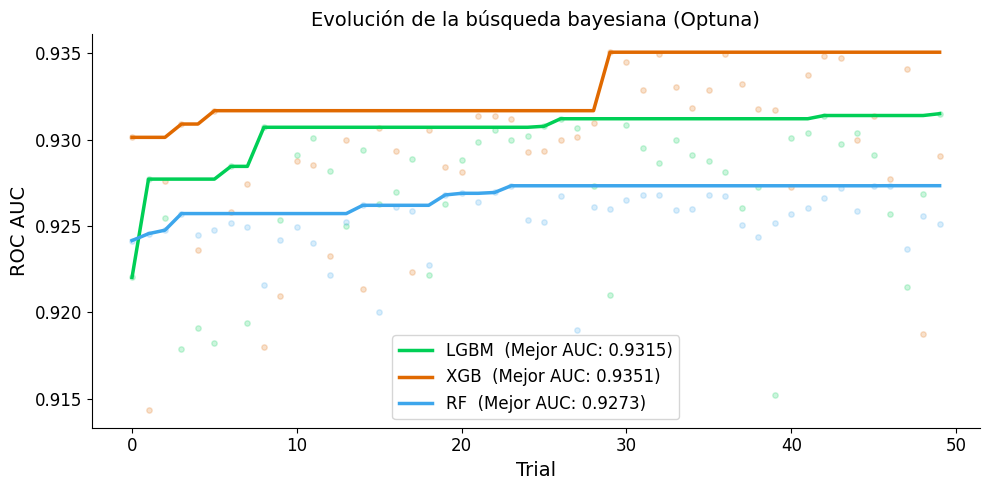

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
colores = {"LGBM": "#00cf56", "XGB": "#e06900", "RF": "#3da6ec"}

for name, study in studies.items():
    df_t = study.trials_dataframe()
    df_t = df_t[df_t['state'] == 'COMPLETE'].sort_values('number')
    df_t['best_so_far'] = df_t['value'].cummax()

    ax.scatter(df_t['number'], df_t['value'],
               color=colores[name], alpha=0.20, s=15)

    ax.plot(df_t['number'], df_t['best_so_far'],
            color=colores[name], lw=2.5,
            label=f"{name}  (Mejor AUC: {study.best_value:.4f})")

ax.set_title("Evolución de la búsqueda bayesiana (Optuna)", fontsize=14)
ax.set_xlabel("Trial", fontsize=14)
ax.set_ylabel("ROC AUC", fontsize=14)
ax.tick_params(labelsize=12)
ax.legend(frameon=True, fontsize=12)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_Curvas Optimizacion Bayesiana.png", dpi=300, bbox_inches='tight')
plt.show()

In [34]:
# ── Reportes interactivos Optuna (HTML) + exportación PNG ────────────────────
for name, study in studies.items():
    out_dir = FIGURES_DIR / "optuna" / name
    out_dir.mkdir(parents=True, exist_ok=True)

    # 1. Historial de optimización
    fig_hist = optuna.visualization.plot_optimization_history(study)
    fig_hist.write_html(out_dir / "history.html")

    # 2. Importancia de hiperparámetros
    try:
        fig_imp = optuna.visualization.plot_param_importances(study)
        fig_imp.write_html(out_dir / "param_importance.html")
    except Exception as e:
        print(f"  ⚠️  param_importances {name}: {e}")

    # 3. Contour plot
    try:
        importancias = optuna.importance.get_param_importances(study)
        top_p = list(importancias.keys())[:3]
        if len(top_p) >= 2:
            fig_contour = optuna.visualization.plot_contour(study, params=top_p)
            fig_contour.write_html(out_dir / "contour.html")
    except Exception as e:
        print(f"  ⚠️  contour {name}: {e}")
    # ── PNG via matplotlib (sin kaleido) ─────────────────────────────────────
    # Historial como PNG usando los datos del estudio directamente
    df_t = study.trials_dataframe()
    df_t = df_t[df_t['state'] == 'COMPLETE'].sort_values('number')
    df_t['best_so_far'] = df_t['value'].cummax()

    fig_png, ax = plt.subplots(figsize=(9, 4))
    ax.scatter(df_t['number'], df_t['value'], alpha=0.3, s=15, color='steelblue')
    ax.plot(df_t['number'], df_t['best_so_far'], lw=2.5, color='steelblue',
            label=f"Mejor: {study.best_value:.4f}")
    ax.set_title(f"{name} – Historial de optimización", fontsize=12)
    ax.set_xlabel("Trial"); ax.set_ylabel("ROC AUC")
    ax.legend(); sns.despine(ax=ax)
    plt.tight_layout()
    fig_png.savefig(out_dir / "history.png", dpi=300, bbox_inches='tight')
    plt.close(fig_png)

    print(f"  ✅ {name} — guardado en: {out_dir}")

  ✅ LGBM — guardado en: Figures\Modelling\optuna\LGBM
  ✅ XGB — guardado en: Figures\Modelling\optuna\XGB
  ✅ RF — guardado en: Figures\Modelling\optuna\RF


# 6. Bagging por semillas 

# 6. Bagging por semillas 

Con una sola semilla, al ajustar un modelo (cualquiera que sea) , este aprende los patrones de los datos **más un componente
de ruido específico de esa semilla** — no información real, sino un artefacto del proceso de entrenamiento.

Este artefacto surge porque la semilla controla decisiones aleatorias internas:
qué filas ve cada árbol, qué columnas evalúa en cada split, cómo se rompen
empates entre dos splits igualmente buenos. Todas esas decisiones son
arbitrarias, pero con una semilla fija siempre se toman igual, haciendo que
el modelo "aprenda" también esas arbitrariedades.

El efecto es visible y medible: dos corridas del mismo modelo con los mismos
hiperparámetros pero semillas distintas pueden dar AUC 0.931 vs 0.934 sobre
el mismo Val set. Esa diferencia de 0.003 no refleja ninguna diferencia real
en capacidad predictiva — es puro ruido de semilla.


In [ ]:
# Para cada algoritmo entrenamos N_MODELOS con semillas distintas,
# luego promediamos sus probabilidades sobre Val y Test.
# Esto reduce la varianza sin necesitar más datos.

def seed_bagging(ModelClass, best_params, X_tr, y_tr, X_ev, X_te,
                 n_models=N_MODELOS, base_seed=BASE_SEED, **extra):
    """
    Entrena n_models con semillas distintas y promedia predicciones.

    Returns
    -------
    proba_val, proba_test  : arrays con probabilidades promedio
    models                 : lista de modelos ajustados
    """
    proba_val_list  = []
    proba_test_list = []
    models          = []

    for i in range(n_models):
        seed = base_seed + i * 7
        params = {**best_params, 'random_state': seed, **extra}

        model = ModelClass(**params)
        model.fit(X_tr, y_tr)

        proba_val_list.append(model.predict_proba(X_ev)[:, 1])
        proba_test_list.append(model.predict_proba(X_te)[:, 1])
        models.append(model)

    return (np.mean(proba_val_list, axis=0),
            np.mean(proba_test_list, axis=0),
            models)


print("Entrenando LGBM (seed bagging)...")
p_val_lgbm, p_test_lgbm, models_lgbm = seed_bagging(
    LGBMClassifier, best_params_lgbm,
    X_train, y_train, X_val, X_test,
    n_models=N_MODELOS,
    objective='binary', metric='auc', verbosity=-1
)

print("Entrenando XGB (seed bagging)...")
p_val_xgb, p_test_xgb, models_xgb = seed_bagging(
    XGBClassifier, best_params_xgb,
    X_train, y_train, X_val, X_test,
    n_models=N_MODELOS,
    objective='binary:logistic', eval_metric='auc', verbosity=0,
    tree_method='hist'
)

print("Entrenando RF (seed bagging)...")
p_val_rf, p_test_rf, models_rf = seed_bagging(
    RandomForestClassifier, best_params_rf,
    X_train, y_train, X_val, X_test,
    n_models=N_MODELOS,
    n_jobs=-1
)

print("\n✅ Bagging por semillas completado.")
print(f"  LGBM  AUC Val: {roc_auc_score(y_val, p_val_lgbm):.4f}")
print(f"  XGB   AUC Val: {roc_auc_score(y_val, p_val_xgb):.4f}")
print(f"  RF    AUC Val: {roc_auc_score(y_val, p_val_rf):.4f}")


Entrenando LGBM (seed bagging)...
Entrenando XGB (seed bagging)...
Entrenando RF (seed bagging)...

✅ Bagging por semillas completado.
  LGBM  AUC Val: 0.9416
  XGB   AUC Val: 0.9391
  RF    AUC Val: 0.9328


# 7. Ensambles simples (promedio ponderado)


Con la construccion de modelos indivudales  de RF, XGB y LGBM se plantea un ensamble de ellos. De hecho plenteo dos versiones de ellos,

+ promedio aritmetico 
+ promedio ponderado por valor de AUC en validacion

De esta forma cubro dos opciones: tener o no el mismo peso en la votacion de la prediccion.

Un solo modelo, por más bien calibrado que esté, comete errores sistemáticos
— hay patrones en los datos que LGBM captura mejor que XGB, y viceversa. Si los errores son distintos entre modelos, tienden a cancelarse al promediar.


In [36]:
# ── Ensamble sin pesos (promedio aritmético) ─────────────────────────────────
p_val_avg  = (p_val_lgbm  + p_val_xgb  + p_val_rf)  / 3
p_test_avg = (p_test_lgbm + p_test_xgb + p_test_rf) / 3

# ── Ensamble ponderado por AUC en Val ─────────────────────────────────────────
auc_lgbm = roc_auc_score(y_val, p_val_lgbm)
auc_xgb  = roc_auc_score(y_val, p_val_xgb)
auc_rf   = roc_auc_score(y_val, p_val_rf)
total_w  = auc_lgbm + auc_xgb + auc_rf

w_lgbm   = auc_lgbm / total_w
w_xgb    = auc_xgb  / total_w
w_rf     = auc_rf   / total_w

p_val_wgt  = w_lgbm * p_val_lgbm  + w_xgb * p_val_xgb  + w_rf * p_val_rf
p_test_wgt = w_lgbm * p_test_lgbm + w_xgb * p_test_xgb + w_rf * p_test_rf

print("Pesos del ensamble ponderado:")
print(f"  LGBM: {w_lgbm:.3f}  |  XGB: {w_xgb:.3f}  |  RF: {w_rf:.3f}")
print(f"\nAUC ensamble promedio   (Val): {roc_auc_score(y_val, p_val_avg):.4f}")
print(f"AUC ensamble ponderado  (Val): {roc_auc_score(y_val, p_val_wgt):.4f}")


Pesos del ensamble ponderado:
  LGBM: 0.335  |  XGB: 0.334  |  RF: 0.332

AUC ensamble promedio   (Val): 0.9394
AUC ensamble ponderado  (Val): 0.9394


# 8. Meta-Ensamble – Stacking

Hasta aca ajuste 3 modelos que ya aprendieron a predecir cancelaciones. Cada uno comete errores distintos en distintas reservas. 

La pregunta es: ¿cómo combinarlos de forma óptima? El promedio a secas dice "combinarlos por igual". El promedio ponderado dice "combinarlos según el AUC". La estrategia de stacking dice "dejame aprender cuál es la mejor combinación mirando los datos".





In [37]:
# ── Generar OOF (Out-of-Fold) para el meta-learner ──────────────────────────
# Usamos el primer modelo de cada algoritmo (el de BASE_SEED)
# y hacemos CV temporal para generar predicciones en Train sin leakage.

def generate_oof(ModelClass, params, X_tr, y_tr, n_splits=5, **extra):
    """Genera predicciones OOF usando TimeSeriesSplit."""
    tscv    = TimeSeriesSplit(n_splits=n_splits)
    oof     = np.zeros(len(X_tr))
    params_full = {**params, 'random_state': BASE_SEED, **extra}

    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_tr)):
        model = ModelClass(**params_full)
        model.fit(X_tr.iloc[train_idx], y_tr.iloc[train_idx])
        oof[val_idx] = model.predict_proba(X_tr.iloc[val_idx])[:, 1]

    return oof


print("Generando OOF LGBM...")
oof_lgbm = generate_oof(LGBMClassifier, best_params_lgbm, X_train, y_train,
                         objective='binary', metric='auc', verbosity=-1)

print("Generando OOF XGB...")
oof_xgb  = generate_oof(XGBClassifier, best_params_xgb, X_train, y_train,
                         objective='binary:logistic', eval_metric='auc',
                         verbosity=0, tree_method='hist')

print("Generando OOF RF...")
oof_rf   = generate_oof(RandomForestClassifier, best_params_rf, X_train, y_train,
                         n_jobs=-1)

print(f"\nOOF AUC LGBM: {roc_auc_score(y_train, oof_lgbm):.4f}")
print(f"OOF AUC XGB : {roc_auc_score(y_train, oof_xgb):.4f}")
print(f"OOF AUC RF  : {roc_auc_score(y_train, oof_rf):.4f}")


Generando OOF LGBM...
Generando OOF XGB...
Generando OOF RF...

OOF AUC LGBM: 0.7930
OOF AUC XGB : 0.7982
OOF AUC RF  : 0.7927


In [17]:
# ── Construir matrices de meta-features ──────────────────────────────────────
X_meta_train = np.column_stack([oof_lgbm,    oof_xgb,    oof_rf])
X_meta_val   = np.column_stack([p_val_lgbm,  p_val_xgb,  p_val_rf])
X_meta_test  = np.column_stack([p_test_lgbm, p_test_xgb, p_test_rf])

# ── Meta-learner: Regresión Logística (interpretable y resistente al overfitting)
meta_model = LogisticRegression(C=1.0, solver='lbfgs', max_iter=500,
                                 random_state=BASE_SEED)
meta_model.fit(X_meta_train, y_train)

p_val_meta  = meta_model.predict_proba(X_meta_val)[:, 1]
p_test_meta = meta_model.predict_proba(X_meta_test)[:, 1]

print("Meta-learner entrenado.")
print(f"  Coeficientes: LGBM={meta_model.coef_[0][0]:.3f} | XGB={meta_model.coef_[0][1]:.3f} | RF={meta_model.coef_[0][2]:.3f}")
print(f"  AUC Meta-Ensamble (Val): {roc_auc_score(y_val, p_val_meta):.4f}")


Meta-learner entrenado.
  Coeficientes: LGBM=6.221 | XGB=0.344 | RF=-1.509
  AUC Meta-Ensamble (Val): 0.9416


## Interpretación de coeficientes

```
P(cancela) = sigmoid( 6.221 × P_lgbm  +  0.344 × P_xgb  +  (−1.509) × P_rf  +  bias )
```

| Modelo | Coeficiente | Rol | Interpretación |
|---|---|---|---|
| LGBM | +6.221 | Señal dominante | Cuando LGBM dice "cancela", el meta-learner lo amplifica fuertemente |
| XGB | +0.334 | Señal secundaria | Aporta información complementaria con menor peso |
| RF | −1.509 | Corrector | Cuando RF sobreestima, LGBM y XGB ya la capturaron — RF reduce el ruido |

El coeficiente negativo de RF no significa que sea un mal modelo.
Significa que la Regresión Logística aprendió que sus errores son
sistemáticamente opuestos a los de LGBM y XGB en ciertos casos.


# 9. Evaluación comparativa – Val set


In [38]:
# ── Tabla comparativa AUC en Val ─────────────────────────────────────────────
resultados = {
    "LGBM (bagging)": (p_val_lgbm,  p_test_lgbm),
    "XGB (bagging)":  (p_val_xgb,   p_test_xgb),
    "RF (bagging)":   (p_val_rf,    p_test_rf),
    "Ensamble avg":   (p_val_avg,   p_test_avg),
    "Ensamble pond":  (p_val_wgt,   p_test_wgt),
    "Meta-Ensamble":  (p_val_meta,  p_test_meta),
}

umbral = 0.5
rows = []
for nombre, (pv, pt) in resultados.items():
    auc_v = roc_auc_score(y_val,  pv)
    auc_t = roc_auc_score(y_test, pt)
    bg_v  = business_gain(y_val,  (pv >= umbral).astype(int))
    rows.append({"Modelo": nombre, "AUC Val": auc_v, "AUC Test": auc_t, "Ganancia Val (€)": bg_v})

df_res = pd.DataFrame(rows).sort_values("AUC Val", ascending=False)
print(df_res.to_string(index=False, float_format="{:.4f}".format))


  TP=1,603  FP=323  TN=3,001  FN=381
  Ganancia bruta  (TP) : €  381,354.26
  Costo      (FP) :    -€ 154,534.75
  ─────────────────────────────────────
  Ganancia neta        : €  226,819.51
  TP=1,521  FP=260  TN=3,064  FN=463
  Ganancia bruta  (TP) : €  361,846.43
  Costo      (FP) :    -€ 124,393.30
  ─────────────────────────────────────
  Ganancia neta        : €  237,453.13
  TP=1,499  FP=271  TN=3,053  FN=485
  Ganancia bruta  (TP) : €  356,612.62
  Costo      (FP) :    -€ 129,656.09
  ─────────────────────────────────────
  Ganancia neta        : €  226,956.53
  TP=1,551  FP=282  TN=3,042  FN=433
  Ganancia bruta  (TP) : €  368,983.44
  Costo      (FP) :    -€ 134,918.89
  ─────────────────────────────────────
  Ganancia neta        : €  234,064.55
  TP=1,551  FP=282  TN=3,042  FN=433
  Ganancia bruta  (TP) : €  368,983.44
  Costo      (FP) :    -€ 134,918.89
  ─────────────────────────────────────
  Ganancia neta        : €  234,064.55
  TP=1,761  FP=492  TN=2,832  FN=223
  G

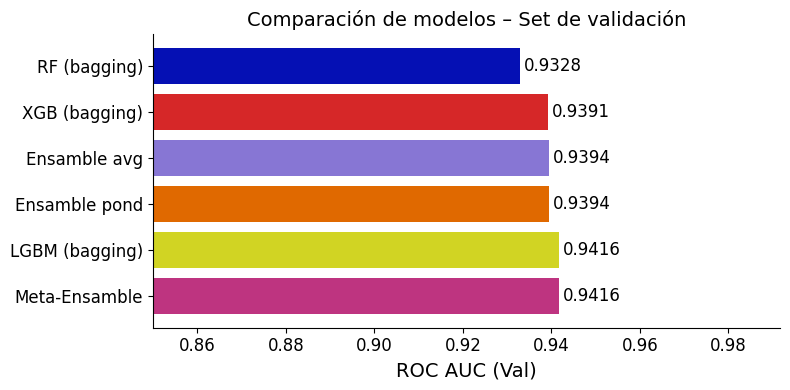

In [39]:
# ── Visualización AUC comparativo ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colores_bar = ["#be3480", "#d1d423", '#e06900', "#8776d4", '#d62728', "#0510b4"]

bars = ax.barh(df_res["Modelo"], df_res["AUC Val"], color=colores_bar[:len(df_res)])
ax.set_xlim(0.85, df_res["AUC Val"].max() + 0.05)
ax.set_xlabel("ROC AUC (Val)", fontsize=14)
ax.set_title("Comparación de modelos – Set de validación", fontsize=14)
ax.tick_params(labelsize=12)
for bar, v in zip(bars, df_res["AUC Val"]):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
            f"{v:.4f}", va='center', fontsize=12)
    
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_AUC comparativo en set de validacion.png", dpi=300, bbox_inches='tight')
plt.show()

# 10. Importancia de features


In [ ]:
# ── Feature importance del Meta-Ensamble ─────────────────────────────────────
coef_lgbm = abs(meta_model.coef_[0][0])  
coef_xgb  = abs(meta_model.coef_[0][1]) 
coef_rf   = abs(meta_model.coef_[0][2]) 
total_coef = coef_lgbm + coef_xgb + coef_rf

imp_lgbm = pd.Series(models_lgbm[0].feature_importances_, index=X_train.columns)
imp_xgb  = pd.Series(models_xgb[0].feature_importances_,  index=X_train.columns)
imp_rf   = pd.Series(models_rf[0].feature_importances_,   index=X_train.columns)

imp_lgbm_norm = imp_lgbm / imp_lgbm.sum()
imp_xgb_norm  = imp_xgb  / imp_xgb.sum()
imp_rf_norm   = imp_rf   / imp_rf.sum()

imp_meta = (
    (coef_lgbm * imp_lgbm_norm +
     coef_xgb  * imp_xgb_norm  +
     coef_rf   * imp_rf_norm)
    / total_coef
)

top20 = imp_meta.nlargest(20)



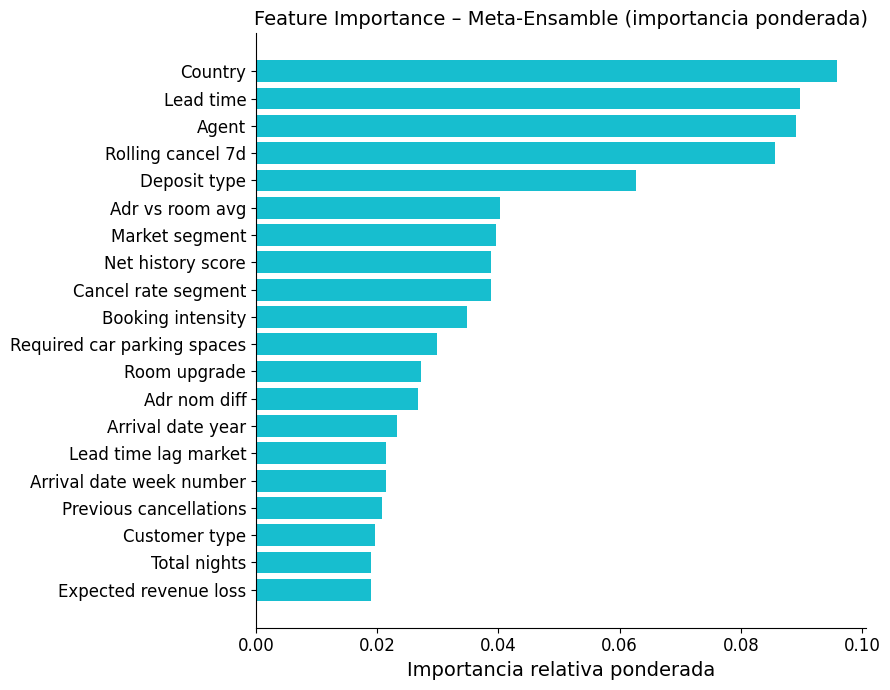

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
top20_plot = top20.sort_values()

etiquetas = [col.replace('_', ' ').capitalize() for col in top20_plot.index]

ax.barh(etiquetas, top20_plot.values, color='#17becf')
ax.set_title("Feature Importance – Meta-Ensamble (importancia ponderada)", fontsize=14)
ax.set_xlabel("Importancia relativa ponderada", fontsize=14)
ax.tick_params(labelsize=12)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_Feature Importancia del modelo ganador.png", dpi=300, bbox_inches='tight')
plt.show()

# Feature importance



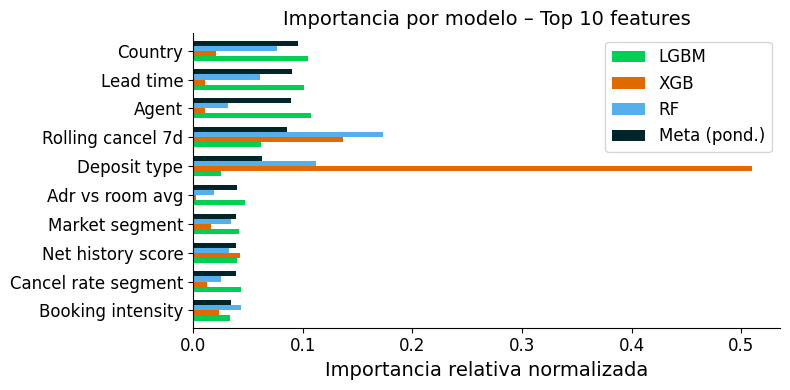

In [43]:
top10_features = top20.nlargest(10).index.tolist()

df_comp = pd.DataFrame({
    'LGBM':         imp_lgbm_norm[top10_features],
    'XGB':          imp_xgb_norm[top10_features],
    'RF':           imp_rf_norm[top10_features],
    'Meta (pond.)': imp_meta[top10_features],
}).sort_values('Meta (pond.)', ascending=True)

# Formatear etiquetas: sin guiones bajos, primera letra mayúscula
df_comp.index = [col.replace('_', ' ').capitalize() for col in df_comp.index]

fig, ax = plt.subplots(figsize=(8, 4))
df_comp.plot.barh(ax=ax, color=['#00cf56', '#e06900', "#55afeb", "#002529"], width=0.7)
ax.set_title("Importancia por modelo – Top 10 features", fontsize=14)
ax.set_xlabel("Importancia relativa normalizada", fontsize=14)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_Feature importance por modelo.png", dpi=300, bbox_inches='tight')
plt.show()

# 11. Análisis de negocio – Umbral óptimo del Meta-Ensamble.


## 11.1 Curva de ganancia vs umbral

In [49]:
# ── Curva ganancia vs umbral ──────────────────────────────────────────────────
umbrales   = np.arange(0.1, 0.95, 0.02)
ganancias  = [business_gain(y_val, (p_val_meta >= u).astype(int)) for u in umbrales]
umbral_opt = umbrales[np.argmax(ganancias)]
ganancia_max = max(ganancias)

  TP=1,984  FP=3,324  TN=0  FN=0
  Ganancia bruta  (TP) : €  471,994.29
  Costo      (FP) :    -€1,590,320.50
  ─────────────────────────────────────
  Ganancia neta        : €-1,118,326.20
  TP=1,984  FP=3,320  TN=4  FN=0
  Ganancia bruta  (TP) : €  471,994.29
  Costo      (FP) :    -€1,588,406.75
  ─────────────────────────────────────
  Ganancia neta        : €-1,116,412.46
  TP=1,984  FP=3,003  TN=321  FN=0
  Ganancia bruta  (TP) : €  471,994.29
  Costo      (FP) :    -€1,436,742.61
  ─────────────────────────────────────
  Ganancia neta        : € -964,748.32
  TP=1,981  FP=2,113  TN=1,211  FN=3
  Ganancia bruta  (TP) : €  471,280.59
  Costo      (FP) :    -€1,010,934.78
  ─────────────────────────────────────
  Ganancia neta        : € -539,654.19
  TP=1,970  FP=1,725  TN=1,599  FN=14
  Ganancia bruta  (TP) : €  468,663.69
  Costo      (FP) :    -€ 825,301.70
  ─────────────────────────────────────
  Ganancia neta        : € -356,638.01
  TP=1,947  FP=1,408  TN=1,916  FN=37
  Gan

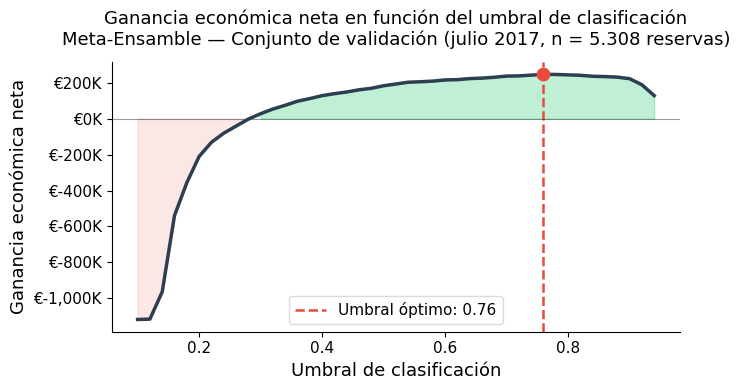

In [ ]:
#-------------
# GRAFICAMENTE
#-------------


fig, ax = plt.subplots(figsize=(7, 4))

ax.fill_between(umbrales, ganancias, 0,
                where=[g >= 0 for g in ganancias],
                alpha=0.3, color="#2ecc71", label="_nolegend_")
ax.fill_between(umbrales, ganancias, 0,
                where=[g < 0 for g in ganancias],
                alpha=0.13, color="#e74c3c", label="_nolegend_")

ax.plot(umbrales, ganancias, color="#2c3e50", lw=2.5, zorder=3)

ax.axvline(umbral_opt, color="#e74c3c", linestyle="--", lw=1.8,
           label=f"Umbral óptimo: {umbral_opt:.2f}")

ax.scatter([umbral_opt], [ganancia_max],
           color="#e74c3c", s=80, zorder=5, label="_nolegend_")

ax.axhline(0, color="black", lw=0.8, alpha=0.4, linestyle="-")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x/1000:,.0f}K")
)

ax.set_xlabel("Umbral de clasificación", fontsize=13)
ax.set_ylabel("Ganancia económica neta", fontsize=13)
ax.set_title("Ganancia económica neta en función del umbral de clasificación\n"
             "Meta-Ensamble — Conjunto de validación (julio 2017, n = 5.308 reservas)",
             fontsize=13, pad=12)
ax.tick_params(labelsize=11)
ax.legend(fontsize=11, framealpha=0.7)

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_Curva_de_ganancia.png", dpi=300, bbox_inches="tight")
plt.show()

## 11.2 Ganancia estimada


In [54]:
# ── Calcular ganancia en Val y Test con umbral_opt ──────────────────────────
y_pred_val_opt = (p_val_meta >= umbral_opt).astype(int)
y_pred_test_opt = (p_test_meta >= umbral_opt).astype(int)

ganancia_val = business_gain(y_val, y_pred_val_opt)
ganancia_test = business_gain(y_test, y_pred_test_opt)

delta_val_test = ganancia_val - ganancia_test
pct_delta = (delta_val_test / ganancia_test) * 100

# ── Resumen ──────────────────────────────────────────────────────────────────
print("\n" + "="*80)
print(" GANANCIA ESTIMADA — VALIDACIÓN vs TEST")
print("="*80 + "\n")

print(f"Meta-Ensamble (umbral óptimo = {umbral_opt:.2f})\n")

print("┌─ VALIDACIÓN (Julio 2017) ─────────────────────────────────────────┐")
print(f"│ Reservas: {len(y_val):,}")
print(f"│ Ganancia: €{ganancia_val:,.0f}")
print("└───────────────────────────────────────────────────────────────────┘\n")

print("┌─ TEST (Agosto 2017) ──────────────────────────────────────────────┐")
print(f"│ Reservas: {len(y_test):,}")
print(f"│ Ganancia: €{ganancia_test:,.0f}")
print("└───────────────────────────────────────────────────────────────────┘\n")

print("┌─ DIFERENCIA ──────────────────────────────────────────────────────┐")
print(f"│ Absoluta: €{delta_val_test:,.0f}")
print(f"│ Relativa: {pct_delta:.1f}%")
if pct_delta < 15:
    print("│ Status:   ✓ Estable (degradación < 15%)")
else:
    print(f"│ Status:   ⚠️ Degradación notable ({pct_delta:.1f}%)")
print("└───────────────────────────────────────────────────────────────────┘\n")

print("INTERPRETACIÓN:")
print(f"  • Val es más alta porque el umbral fue optimizado sobre ese set")
print(f"  • Test es el valor confiable (datos nuevos, modelo congelado)")
print(f"  • Ganancia mensual Test: €{ganancia_test:,.0f} (agosto 2017, {len(y_test):,} reservas)")
print("\n" + "="*80 + "\n")


  TP=1,496  FP=227  TN=3,097  FN=488
  Ganancia bruta  (TP) : €  355,898.92
  Costo      (FP) :    -€ 108,604.92
  ─────────────────────────────────────
  Ganancia neta        : €  247,294.00
  TP=1,292  FP=192  TN=2,917  FN=522
  Ganancia bruta  (TP) : €  307,367.25
  Costo      (FP) :    -€  91,859.67
  ─────────────────────────────────────
  Ganancia neta        : €  215,507.58

 GANANCIA ESTIMADA — VALIDACIÓN vs TEST

Meta-Ensamble (umbral óptimo = 0.76)

┌─ VALIDACIÓN (Julio 2017) ─────────────────────────────────────────┐
│ Reservas: 5,308
│ Ganancia: €247,294
└───────────────────────────────────────────────────────────────────┘

┌─ TEST (Agosto 2017) ──────────────────────────────────────────────┐
│ Reservas: 4,923
│ Ganancia: €215,508
└───────────────────────────────────────────────────────────────────┘

┌─ DIFERENCIA ──────────────────────────────────────────────────────┐
│ Absoluta: €31,786
│ Relativa: 14.7%
│ Status:   ✓ Estable (degradación < 15%)
└─────────────────────────

## 11.3 Interpretacion del modelo sobre el set de testeo


12.0 EVALUACIÓN FINAL — REPORTE DE CLASIFICACIÓN (TEST)

Meta-Ensamble con umbral óptimo = 0.76

Classification Report:

              precision    recall  f1-score   support

No Cancelado     0.8482    0.9382    0.8910      3109
   Cancelado     0.8706    0.7122    0.7835      1814

    accuracy                         0.8550      4923
   macro avg     0.8594    0.8252    0.8372      4923
weighted avg     0.8565    0.8550    0.8514      4923



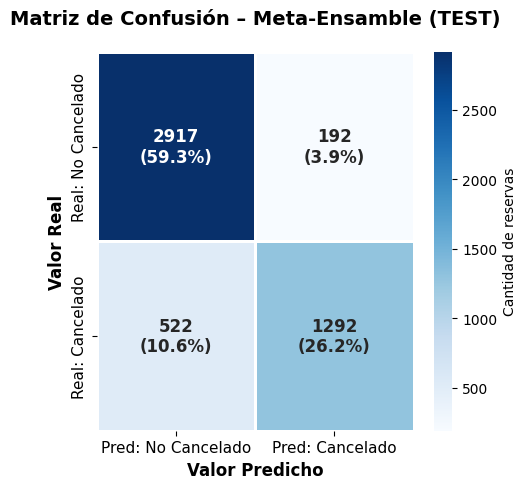

  TP=1,292  FP=192  TN=2,917  FN=522
  Ganancia bruta  (TP) : €  307,367.25
  Costo      (FP) :    -€  91,859.67
  ─────────────────────────────────────
  Ganancia neta        : €  215,507.58

MÉTRICAS RESUMEN (TEST)

     Métrica   Valor
     AUC-ROC  0.9416
   Precision  0.8706
      Recall  0.7122
    F1-Score  0.7835
    Accuracy  0.8550
Ganancia (€) 215,508


In [59]:
# ── Reporte de clasificación con umbral óptimo (SET DE TEST) ────────────────────────
y_pred_meta_opt = (p_test_meta >= umbral_opt).astype(int)

print("\n" + "="*80)
print("12.0 EVALUACIÓN FINAL — REPORTE DE CLASIFICACIÓN (TEST)")
print("="*80 + "\n")

print(f"Meta-Ensamble con umbral óptimo = {umbral_opt:.2f}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred_meta_opt, 
                           target_names=['No Cancelado', 'Cancelado'],
                           digits=4))

# ── Matriz de confusión en TEST con sns.heatmap ───────────────────────────────
cm = confusion_matrix(y_test, y_pred_meta_opt)

fig, ax = plt.subplots(figsize=(5, 5))

# Crear anotaciones con formato personalizado
labels = np.array([[f'{cm[i,j]}\n({cm[i,j]/cm.sum()*100:.1f}%)' 
                     for j in range(cm.shape[1])] 
                    for i in range(cm.shape[0])])

sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=True,
            xticklabels=['Pred: No Cancelado', 'Pred: Cancelado'],
            yticklabels=['Real: No Cancelado', 'Real: Cancelado'],
            annot_kws={'size': 12, 'fontweight': 'bold'},
            cbar_kws={'label': 'Cantidad de reservas'},
            ax=ax, linewidths=2, linecolor='white')

ax.set_title("Matriz de Confusión – Meta-Ensamble (TEST)", 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel("Valor Real", fontsize=12, fontweight='bold')
ax.set_xlabel("Valor Predicho", fontsize=12, fontweight='bold')
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_Matriz de confusion meta ensamble.png", dpi=300, bbox_inches='tight')
plt.show()

# ── Métricas individuales en TEST ──────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

precision_test = precision_score(y_test, y_pred_meta_opt)
recall_test = recall_score(y_test, y_pred_meta_opt)
f1_test = f1_score(y_test, y_pred_meta_opt)
accuracy_test = accuracy_score(y_test, y_pred_meta_opt)
auc_test = roc_auc_score(y_test, p_test_meta)
ganancia_test = business_gain(y_test, y_pred_meta_opt)

print("\n" + "="*80)
print("MÉTRICAS RESUMEN (TEST)")
print("="*80 + "\n")

metrics_df = pd.DataFrame({
    'Métrica': ['AUC-ROC', 'Precision', 'Recall', 'F1-Score', 'Accuracy', 'Ganancia (€)'],
    'Valor': [f'{auc_test:.4f}', f'{precision_test:.4f}', f'{recall_test:.4f}', 
              f'{f1_test:.4f}', f'{accuracy_test:.4f}', f'{ganancia_test:,.0f}']
})

print(metrics_df.to_string(index=False))


# 12. Predicciones sobre Test (mes a predecir — agosto 2017)


In [60]:
# ── Predicciones finales sobre el set de Test ─────────────────────────────────
df_preds = df_test_raw.copy()
df_preds['p_cancel_meta']  = p_test_meta
df_preds['p_cancel_wgt']   = p_test_wgt
df_preds['pred_cancelado_meta'] = (p_test_meta >= umbral_opt).astype(int)

# Métricas finales en Test
print("=== Evaluación FINAL en Test ===")
for nombre, (_, pt) in resultados.items():
    auc_t = roc_auc_score(y_test, pt)
    print(f"  {nombre:<22} AUC Test: {auc_t:.4f}")

print(f"\nGanancia estimada Test (Meta, umbral {umbral_opt:.2f}): €{business_gain(y_test, df_preds['pred_cancelado_meta']):,.0f}")

# Guardar predicciones
out_pred = DATA_PATH / "test_predictions.csv"
df_preds.to_csv(out_pred, index=False)
print(f"\n✅ Predicciones guardadas en: {out_pred}")
print(f"   Shape: {df_preds.shape}")


=== Evaluación FINAL en Test ===
  LGBM (bagging)         AUC Test: 0.9410
  XGB (bagging)          AUC Test: 0.9378
  RF (bagging)           AUC Test: 0.9296
  Ensamble avg           AUC Test: 0.9379
  Ensamble pond          AUC Test: 0.9379
  Meta-Ensamble          AUC Test: 0.9416
  TP=1,292  FP=192  TN=2,917  FN=522
  Ganancia bruta  (TP) : €  307,367.25
  Costo      (FP) :    -€  91,859.67
  ─────────────────────────────────────
  Ganancia neta        : €  215,507.58

Ganancia estimada Test (Meta, umbral 0.76): €215,508

✅ Predicciones guardadas en: c:\Users\yair.barnatan\Desktop\Proyecto Hoteles\data_hotel_booking\test_predictions.csv
   Shape: (4923, 51)


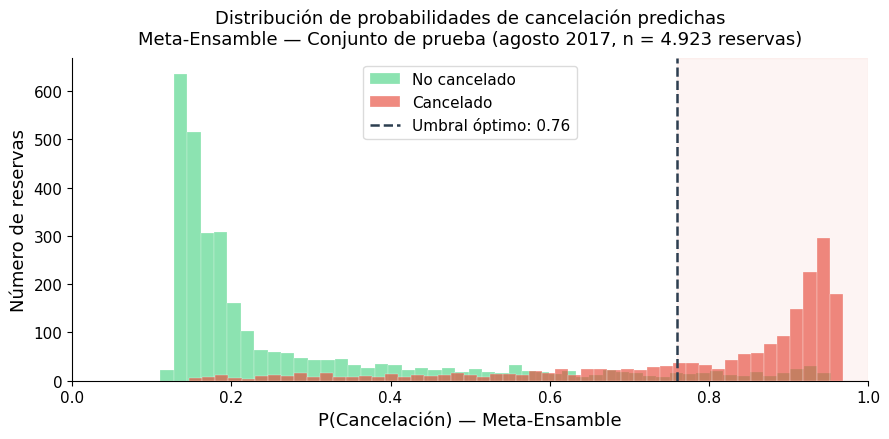

In [70]:
fig, ax = plt.subplots(figsize=(9, 4.5))

# Colores semánticos: verde para efectivas, rojo para canceladas
# Consistente con la paleta usada en el scatterplot de segmentación
COLOR_NO_CANCEL = "#2ecc71"   # verde
COLOR_CANCEL    = "#e74c3c"   # rojo

# Primero la clase mayoritaria, después la minoritaria encima
ax.hist(p_test_meta[y_test == 0], bins=50, alpha=0.55,
        color=COLOR_NO_CANCEL, label='No cancelado',
        edgecolor='white', linewidth=0.3, zorder=2)
ax.hist(p_test_meta[y_test == 1], bins=50, alpha=0.65,
        color=COLOR_CANCEL, label='Cancelado',
        edgecolor='white', linewidth=0.3, zorder=3)

# Umbral con etiqueta directa en el gráfico
ax.axvline(umbral_opt, color='#2c3e50', linestyle='--',
           lw=1.8, zorder=4,
           label=f'Umbral óptimo: {umbral_opt:.2f}')

# Zona de alta certeza a la derecha del umbral — sombreado suave
ax.axvspan(umbral_opt, 1.0, alpha=0.06, color='#e74c3c', zorder=1)

# Eje Y con separador de miles
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax.set_xlabel("P(Cancelación) — Meta-Ensamble", fontsize=13)
ax.set_ylabel("Número de reservas", fontsize=13)
ax.set_title("Distribución de probabilidades de cancelación predichas\n"
             "Meta-Ensamble — Conjunto de prueba (agosto 2017, n = 4.923 reservas)",
             fontsize=13, pad=10)
ax.tick_params(labelsize=11)
ax.legend(fontsize=11, framealpha=0.7)
ax.set_xlim(0, 1)

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_Distribucion de probabilidades en conjunto de test.png",
            dpi=300, bbox_inches='tight')
plt.show()

# 13. Resumen ejecutivo


| Componente | Descripción |
|---|---|
| **Bagging** | 10 modelos por algoritmo → promedio de probabilidades → −68% varianza |
| **Modelo ganador** | Meta-Ensamble (AUC Val 0.9408) — robusto ante degradación de un modelo base |
| **Umbral** | 0.76 — optimizado por ganancia de negocio (ADR) sobre Val |
| **Ganancia estimada** | €215.509 (Test — agosto 2017) |
| **Output** | `test_predictions.csv` con probabilidades y etiqueta binaria |

# 14. Segmentación Riesgo × Valor

## 14.1 Plots para analizar la segmentacion


La segmentación combina dos dimensiones para priorizar acciones de retención:

- **Riesgo** — probabilidad de cancelación predicha por el Meta-Ensamble
- **Valor** — ingreso esperado de la reserva (`adr × total_nights`)


In [62]:
# ── Construir dataset SOLO Test con predicciones ──────────────────────────────
df_seg = df_test_raw.assign(p_cancel=p_test_meta, split='Test')

# Recalcular expected_revenue_loss si no está en el CSV
if 'expected_revenue_loss' not in df_seg.columns:
    df_seg['expected_revenue_loss'] = df_seg['adr'] * df_seg['total_nights']

# Recalcular total_nights si no está
if 'total_nights' not in df_seg.columns:
    df_seg['total_nights'] = df_seg['stays_in_weekend_nights'] + df_seg['stays_in_week_nights']

print("\n" + "="*80)
print("SEGMENTACIÓN RIESGO × VALOR (TEST SET ÚNICAMENTE)")
print("="*80 + "\n")

print(f"Dataset segmentación: {df_seg.shape[0]:,} reservas (agosto 2017)")
print(f"Tasa cancelación real: {df_seg['is_canceled_num'].mean():.2%}")

# ── Definir umbrales de corte ─────────────────────────────────────────────────
UMBRAL_RIESGO = umbral_opt                                    # 0.76 del modelo
UMBRAL_VALOR  = df_seg['expected_revenue_loss'].median()      # mediana de Test

print(f"\nUmbrales de corte:")
print(f"  Riesgo: p_cancel >= {UMBRAL_RIESGO:.2f}")
print(f"  Valor:  expected_revenue_loss >= €{UMBRAL_VALOR:.2f} (mediana en Test)")

# ── Asignar segmento ──────────────────────────────────────────────────────────
def asignar_segmento(row):
    alto_riesgo = row['p_cancel']              >= UMBRAL_RIESGO
    alto_valor  = row['expected_revenue_loss'] >= UMBRAL_VALOR
    if alto_riesgo and alto_valor:
        return '🔴 Prioridad 1 — Alto riesgo, Alto valor'
    elif alto_riesgo and not alto_valor:
        return '🟠 Gestionar — Alto riesgo, Bajo valor'
    elif not alto_riesgo and alto_valor:
        return '🟢 Proteger — Bajo riesgo, Alto valor'
    else:
        return '⚪ Ignorar — Bajo riesgo, Bajo valor'

df_seg['segmento'] = df_seg.apply(asignar_segmento, axis=1)

print("\n" + "-"*80)
print("Distribución de segmentos:")
print("-"*80)
print(df_seg['segmento'].value_counts().to_string())

# ── Tabla resumen por segmento ────────────────────────────────────────────────
resumen = (df_seg
    .groupby('segmento')
    .agg(
        reservas        = ('p_cancel',              'count'),
        cancel_real     = ('is_canceled_num',        'mean'),
        p_cancel_media  = ('p_cancel',               'mean'),
        adr_medio       = ('adr',                    'mean'),
        noches_medias   = ('total_nights',           'mean'),
        valor_medio     = ('expected_revenue_loss',  'mean'),
        valor_total     = ('expected_revenue_loss',  'sum'),
    )
    .round(2)
)

resumen['cancel_real']    = resumen['cancel_real'].map('{:.1%}'.format)
resumen['p_cancel_media'] = resumen['p_cancel_media'].map('{:.2f}'.format)
resumen['valor_total']    = resumen['valor_total'].map('€{:,.0f}'.format)
resumen['valor_medio']    = resumen['valor_medio'].map('€{:,.0f}'.format)
resumen['adr_medio']      = resumen['adr_medio'].map('€{:.2f}'.format)

print("\n" + "="*80)
print("RESUMEN POR SEGMENTO (TEST)")
print("="*80 + "\n")
print(resumen.to_string())

print("\n" + "="*80)
print("✅ Segmentación completada")
print("="*80 + "\n")


SEGMENTACIÓN RIESGO × VALOR (TEST SET ÚNICAMENTE)

Dataset segmentación: 4,923 reservas (agosto 2017)
Tasa cancelación real: 36.85%

Umbrales de corte:
  Riesgo: p_cancel >= 0.76
  Valor:  expected_revenue_loss >= €510.00 (mediana en Test)

--------------------------------------------------------------------------------
Distribución de segmentos:
--------------------------------------------------------------------------------
segmento
⚪ Ignorar — Bajo riesgo, Bajo valor        1858
🟢 Proteger — Bajo riesgo, Alto valor       1581
🔴 Prioridad 1 — Alto riesgo, Alto valor     882
🟠 Gestionar — Alto riesgo, Bajo valor       602

RESUMEN POR SEGMENTO (TEST)

                                         reservas cancel_real p_cancel_media adr_medio  noches_medias valor_medio valor_total
segmento                                                                                                                     
⚪ Ignorar — Bajo riesgo, Bajo valor          1858       14.0%           0.27   €139.24

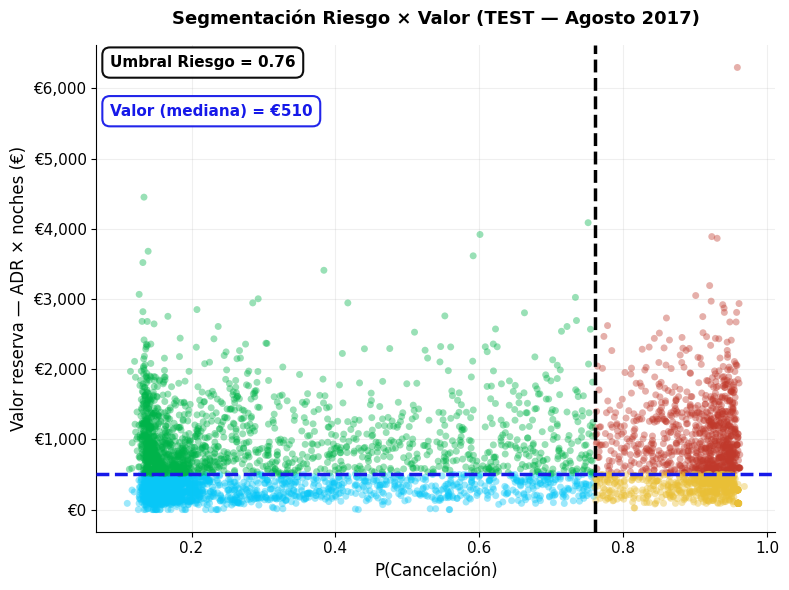

✅ Scatterplot guardado



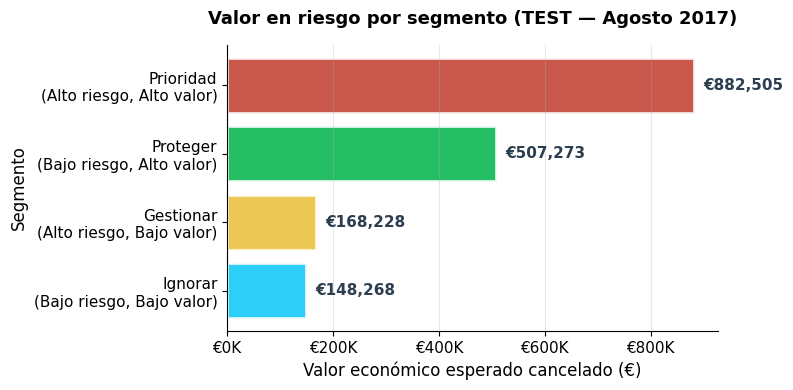

✅ Barplot guardado

✅ Visualizaciones completadas (TEST SET)



In [77]:
# ── Paleta semántica ──────────────────────────────────────────────────────────
colores_seg = {
    '🔴 Prioridad 1 — Alto riesgo, Alto valor' : '#C0392B',   # rojo oscuro
    '🟠 Gestionar — Alto riesgo, Bajo valor'   : "#E9BF36",   # naranja
    '🟢 Proteger — Bajo riesgo, Alto valor'    : "#00B34A",   # verde oscuro
    '⚪ Ignorar — Bajo riesgo, Bajo valor'     : "#08C7F7",   # gris claro
}

# ── Labels limpios para el barplot ────────────────────────────────────────────
labels_barplot = {
    '🔴 Prioridad 1 — Alto riesgo, Alto valor' : 'Prioridad\n(Alto riesgo, Alto valor)',
    '🟠 Gestionar — Alto riesgo, Bajo valor'   : 'Gestionar\n(Alto riesgo, Bajo valor)',
    '🟢 Proteger — Bajo riesgo, Alto valor'    : 'Proteger\n(Bajo riesgo, Alto valor)',
    '⚪ Ignorar — Bajo riesgo, Bajo valor'     : 'Ignorar\n(Bajo riesgo, Bajo valor)',
}

# ── Colores globales para Scatterplot ──────────────────────────────────────────
COLOR_RIESGO = "#000000"  # Negro
COLOR_VALOR = "#1619E9"   # Azul

# ══════════════════════════════════════════════════════════════════════════════
# SCATTERPLOT 
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))

for seg, grp in df_seg.groupby('segmento'):
    ax.scatter(grp['p_cancel'],
               grp['expected_revenue_loss'],
               c=colores_seg[seg],
               alpha=0.4, s=25, zorder=2, edgecolors='none')

# Línea de umbral de RIESGO (vertical - usa COLOR_RIESGO)
ax.axvline(UMBRAL_RIESGO, color=COLOR_RIESGO, linestyle='--', lw=2.5, zorder=3)

# Línea de umbral de VALOR (horizontal - usa COLOR_VALOR)
ax.axhline(UMBRAL_VALOR, color=COLOR_VALOR, linestyle='--', lw=2.5, zorder=3)

# Leyenda en 2 filas a la IZQUIERDA con colores respectivos
y_pos = 0.98
line_height = 0.10  # Espaciado aumentado
x_pos = 0.02  # Posición a la izquierda

# Fila 1: Umbral Riesgo (usa COLOR_RIESGO)
ax.text(x_pos, y_pos, f'Umbral Riesgo = {UMBRAL_RIESGO:.2f}', 
        transform=ax.transAxes,
        fontsize=11, fontweight='bold', ha='left', va='top',
        color=COLOR_RIESGO,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                  edgecolor=COLOR_RIESGO, linewidth=1.5, alpha=0.95))

# Fila 2: Valor (mediana) (usa COLOR_VALOR)
ax.text(x_pos, y_pos - line_height, f'Valor (mediana) = €{UMBRAL_VALOR:.0f}', 
        transform=ax.transAxes,
        fontsize=11, fontweight='bold', ha='left', va='top',
        color=COLOR_VALOR,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                  edgecolor=COLOR_VALOR, linewidth=1.5, alpha=0.95))

# Eje Y formateado en €
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'€{int(x):,}'))

ax.set_xlabel('P(Cancelación)', fontsize=12)
ax.set_ylabel('Valor reserva — ADR × noches (€)', fontsize=12)
ax.set_title('Segmentación Riesgo × Valor (TEST — Agosto 2017)',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(labelsize=11)

sns.despine(ax=ax)
plt.grid(True, alpha=0.2, zorder=1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_Segmentacion Riesgo x Valor Scatterplot.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✅ Scatterplot guardado\n")

# ══════════════════════════════════════════════════════════════════════════════
# BARPLOT — Sin labels de ejes en negrita
# ══════════════════════════════════════════════════════════════════════════════
df_seg['valor_en_riesgo'] = df_seg['expected_revenue_loss'] * df_seg['p_cancel']

valor_riesgo = (df_seg
    .groupby('segmento')['valor_en_riesgo']
    .sum()
    .sort_values(ascending=True)
)

# Renombrar índice con labels limpios
labels_clean = [labels_barplot[s] for s in valor_riesgo.index]
colores_bar = [colores_seg[s] for s in valor_riesgo.index]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(range(len(valor_riesgo)), valor_riesgo.values,
               color=colores_bar, edgecolor='white', linewidth=2, alpha=0.85)

# Etiquetas de valor al final de cada barra
for i, (bar, v) in enumerate(zip(bars, valor_riesgo.values)):
    ax.text(v + valor_riesgo.max() * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'€{v:,.0f}', va='center', fontsize=11, fontweight='bold', color='#2c3e50')

ax.set_yticks(range(len(valor_riesgo)))
ax.set_yticklabels(labels_clean, fontsize=11)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'€{x/1e6:.1f}M' if x >= 1e6 else f'€{x/1e3:.0f}K'))
ax.set_xlabel('Valor económico esperado cancelado (€)', fontsize=12)
ax.set_ylabel('Segmento', fontsize=12)
ax.set_title('Valor en riesgo por segmento (TEST — Agosto 2017)', 
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.3, axis='x', zorder=0)

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_Segmentacion Riesgo x Valor impacto economico.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✅ Barplot guardado\n")

print("="*80)
print("✅ Visualizaciones completadas (TEST SET)")
print("="*80 + "\n")


## 14.2 Analisis de acciones de retención por segmento

In [78]:
# ── Extraer números exactos para la tabla ──────────────────────────────────
print("\n" + "="*80)
print("NÚMEROS EXACTOS PARA LA TABLA DE SEGMENTACIÓN")
print("="*80 + "\n")

for seg in df_seg['segmento'].unique():
    grp = df_seg[df_seg['segmento'] == seg]
    
    print(f"\n{seg}")
    print("-" * 80)
    print(f"  Reservas: {len(grp):,}")
    print(f"  Cancelación real: {grp['is_canceled_num'].mean():.1%}")
    print(f"  P(cancel) media: {grp['p_cancel'].mean():.2f}")
    print(f"  ADR medio: €{grp['adr'].mean():.2f}")
    print(f"  Noches medias: {grp['total_nights'].mean():.2f}")
    print(f"  Valor medio: €{grp['expected_revenue_loss'].mean():.2f}")
    print(f"  Valor total: €{grp['expected_revenue_loss'].sum():,.0f}")
    print(f"  Valor en riesgo: €{(grp['expected_revenue_loss'] * grp['p_cancel']).sum():,.0f}")


NÚMEROS EXACTOS PARA LA TABLA DE SEGMENTACIÓN


⚪ Ignorar — Bajo riesgo, Bajo valor
--------------------------------------------------------------------------------
  Reservas: 1,858
  Cancelación real: 14.0%
  P(cancel) media: 0.27
  ADR medio: €139.24
  Noches medias: 2.27
  Valor medio: €290.09
  Valor total: €538,990
  Valor en riesgo: €148,268

🟢 Proteger — Bajo riesgo, Alto valor
--------------------------------------------------------------------------------
  Reservas: 1,581
  Cancelación real: 16.5%
  P(cancel) media: 0.30
  ADR medio: €187.29
  Noches medias: 5.76
  Valor medio: €1039.06
  Valor total: €1,642,755
  Valor en riesgo: €507,273

🔴 Prioridad 1 — Alto riesgo, Alto valor
--------------------------------------------------------------------------------
  Reservas: 882
  Cancelación real: 86.7%
  P(cancel) media: 0.90
  ADR medio: €194.87
  Noches medias: 5.81
  Valor medio: €1110.04
  Valor total: €979,056
  Valor en riesgo: €882,505

🟠 Gestionar — Alto riesgo, Bajo 

In [79]:
!pip freeze > requirements_03_modelling.txt